In [14]:
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt
import os
from chart_studio.plotly import plot,iplot
import cufflinks as cf
import seaborn as sns
%matplotlib inline

In [15]:
os.chdir('D:\\topmentor\\Cohort 127_ML_ Day 49\\Flight Price Prediction\\')

In [16]:
df=pd.read_excel('Data_Train.xlsx')
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [24]:
from ydata_profiling import ProfileReport
display(ProfileReport(df))



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 12.50it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [26]:
# To check the null vaues in df DataFrame
print(df.isnull().sum())

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64


In [ ]:
# now deleted the null values from the datasets using DataFrame.dropna(how='any',inplace=True)

In [27]:
df.dropna(how='any',inplace=True)

In [28]:
print(df.isnull().sum())

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64


In [29]:
df.shape

(10682, 11)

In [30]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [31]:
df['Date_of_Journey']=pd.to_datetime(df['Date_of_Journey']) # to change the string(object) to datetime

C:\temp\ipykernel_14724\541643806.py:1: UserWarning:

Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [32]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [33]:
df.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time                   object
Arrival_Time               object
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [34]:
df['Date_of_Journey'].dt.day

0        24
1         1
2         9
3        12
4         1
         ..
10678     9
10679    27
10680    27
10681     1
10682     9
Name: Date_of_Journey, Length: 10682, dtype: int32

In [35]:
df['Day_of_Journey']=(df['Date_of_Journey']).dt.day # day column added in the df datasets
df['Month_of_Journey']=(df['Date_of_Journey']).dt.month # month column added in the df datasets

In [38]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


In [37]:
df.dtypes

Airline                     object
Date_of_Journey     datetime64[ns]
Source                      object
Destination                 object
Route                       object
Dep_Time                    object
Arrival_Time                object
Duration                    object
Total_Stops                 object
Additional_Info             object
Price                        int64
Day_of_Journey               int32
Month_of_Journey             int32
dtype: object

In [39]:
df.drop('Date_of_Journey',axis=1)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


In [44]:
pd.to_datetime(df['Dep_Time']).dt.minute

C:\temp\ipykernel_14724\588458865.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



0        20
1        50
2        25
3         5
4        50
         ..
10678    55
10679    45
10680    20
10681    30
10682    55
Name: Dep_Time, Length: 10682, dtype: int32

In [45]:
df['Dep_hr']=pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_min']=pd.to_datetime(df['Dep_Time']).dt.minute

C:\temp\ipykernel_14724\3139959137.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\temp\ipykernel_14724\3139959137.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [46]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [47]:
df.drop(['Dep_Time'],axis=1,inplace=True)

In [49]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,22:25,2h 30m,non-stop,No info,4107,9,4,19,55
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,23:20,2h 35m,non-stop,No info,4145,27,4,20,45
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,11:20,3h,non-stop,No info,7229,27,4,8,20
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,14:10,2h 40m,non-stop,No info,12648,1,3,11,30


In [51]:
df['Arrival_hr']=pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_min']=pd.to_datetime(df['Arrival_Time']).dt.minute

C:\temp\ipykernel_14724\2014546864.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\temp\ipykernel_14724\2014546864.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [52]:
display(df.head())

,Airline,Date_of_Journey,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [59]:
df.drop(['Arrival_Time'],axis=1,inplace=True)

In [60]:
display(df)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,2h 30m,non-stop,No info,4107,9,4,19,55,22,25
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,2h 35m,non-stop,No info,4145,27,4,20,45,23,20
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,3h,non-stop,No info,7229,27,4,8,20,11,20
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,2h 40m,non-stop,No info,12648,1,3,11,30,14,10


In [61]:
display(df['Duration'])

0        2h 50m
1        7h 25m
2           19h
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680        3h
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

In [62]:
duration=df['Duration'].str.split(' ',expand=True)
display(duration)

,0,1
0,2h,50m
1,7h,25m
2,19h,None
3,5h,25m
4,4h,45m
...,...,...
10678,2h,30m
10679,2h,35m
10680,3h,None
10681,2h,40m


In [ ]:
# now convert the none value in duration DataFrame into 00m using fillna

In [63]:
duration[1].fillna('00m',inplace=True)
display(duration)

C:\temp\ipykernel_14724\2829618441.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,0,1
0,2h,50m
1,7h,25m
2,19h,00m
3,5h,25m
4,4h,45m
...,...,...
10678,2h,30m
10679,2h,35m
10680,3h,00m
10681,2h,40m


In [87]:
df['duration_hr']=duration[0].apply(lambda x: x[:-1] )
display(df)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10,2
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15,7
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25,19
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,2h 30m,non-stop,No info,4107,9,4,19,55,22,25,2
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,2h 35m,non-stop,No info,4145,27,4,20,45,23,20,2
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,3h,non-stop,No info,7229,27,4,8,20,11,20,3
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,2h 40m,non-stop,No info,12648,1,3,11,30,14,10,2


In [90]:
df['duration_min']=duration[1].apply(lambda x: x[:-1])

In [91]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr,duration_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,2h 30m,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,2h 35m,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,3h,non-stop,No info,7229,27,4,8,20,11,20,3,00
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,2h 40m,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [92]:
df.drop(['Duration'],axis=1,inplace=True)

In [93]:
display(df)

,Airline,Date_of_Journey,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr,duration_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,00
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [94]:
df.drop(['Date_of_Journey'],axis=1,inplace=True)

In [95]:
display(df)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr,duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,Air India,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,00
10681,Vistara,Banglore,New Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [96]:
cf.set_config_file(theme='ggplot',sharing='public',offline=True)

In [103]:
df.Airline.value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [ ]:
# show the against Airline vs avg prices

In [105]:
df.groupby(['Airline','Source','Destination'])['Price'].mean().sort_values(ascending=False)

Airline                            Source    Destination
Jet Airways Business               Banglore  New Delhi      62844.250000
                                   Delhi     Cochin         49387.500000
Jet Airways                        Banglore  New Delhi      15101.272727
                                   Delhi     Cochin         12642.593317
Vistara                            Mumbai    Hyderabad      12326.521739
Vistara Premium economy            Banglore  New Delhi      11793.000000
Jet Airways                        Kolkata   Banglore       11717.565287
Multiple carriers Premium economy  Delhi     Cochin         11418.846154
Air India                          Banglore  New Delhi      11045.575472
Multiple carriers                  Delhi     Cochin         10902.678094
Air India                          Kolkata   Banglore       10357.324219
                                   Delhi     Cochin         10003.446381
Vistara                            Kolkata   Banglore        9257.6

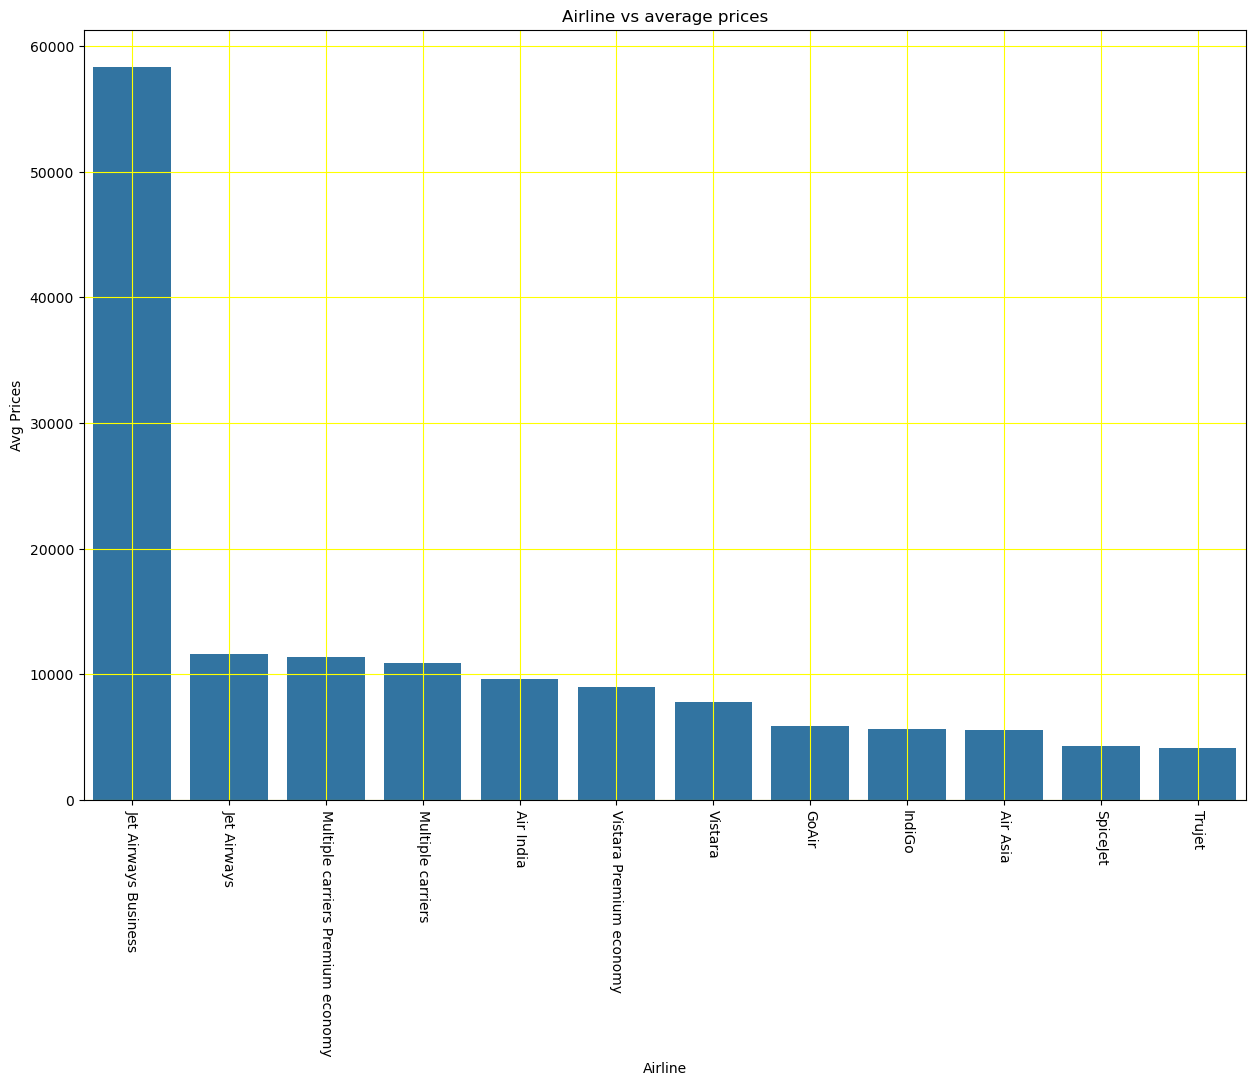

In [119]:
Airprices=df.groupby(['Airline'])['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,10))
sns.barplot(x=Airprices.index,y=Airprices.values)
plt.xticks(rotation=270)
plt.title('Airline vs average prices')
plt.xlabel('Airline')
plt.ylabel('Avg Prices')
plt.grid(True,color='yellow')
plt.show()

In [111]:
print((Airprices))

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11643.923357
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9612.427756
Vistara Premium economy               8962.333333
Vistara                               7796.348643
GoAir                                 5861.056701
IndiGo                                5673.682903
Air Asia                              5590.260188
SpiceJet                              4338.284841
Trujet                                4140.000000
Name: Price, dtype: float64


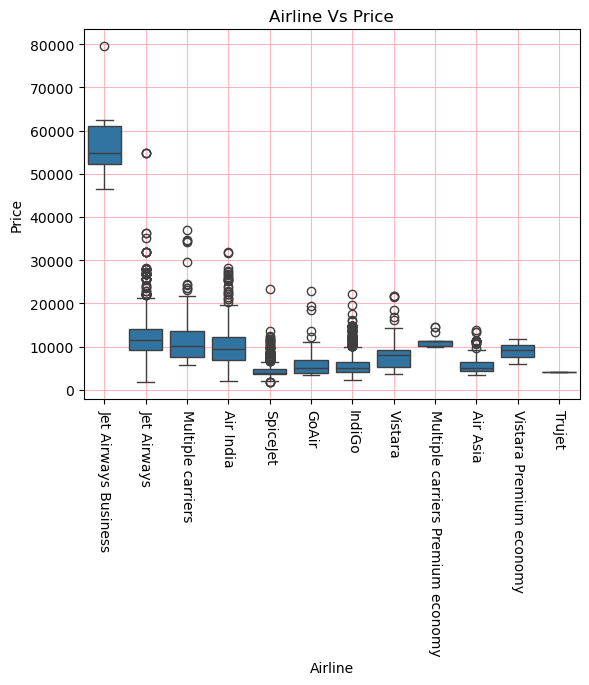

In [125]:
sns.boxplot(x='Airline',y='Price',data=df.sort_values('Price',ascending=False))
plt.title('Airline Vs Price')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.xticks(rotation=270)
plt.grid(True,color='lightpink')
plt.show()

In [126]:
df.groupby(['Airline','Total_Stops'])['Price'].mean()

Airline                            Total_Stops
Air Asia                           1 stop          7078.325581
                                   2 stops         6341.888889
                                   non-stop        4492.331492
Air India                          1 stop          9041.509259
                                   2 stops        12092.779101
                                   3 stops        12208.054054
                                   4 stops        17686.000000
                                   non-stop        5605.326139
GoAir                              1 stop          6884.676471
                                   non-stop        4726.173913
IndiGo                             1 stop          7104.717528
                                   2 stops         7507.526316
                                   non-stop        4731.174053
Jet Airways                        1 stop         12512.741223
                                   2 stops        13387.247467
        

C:\temp\ipykernel_14724\2588482509.py:3: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



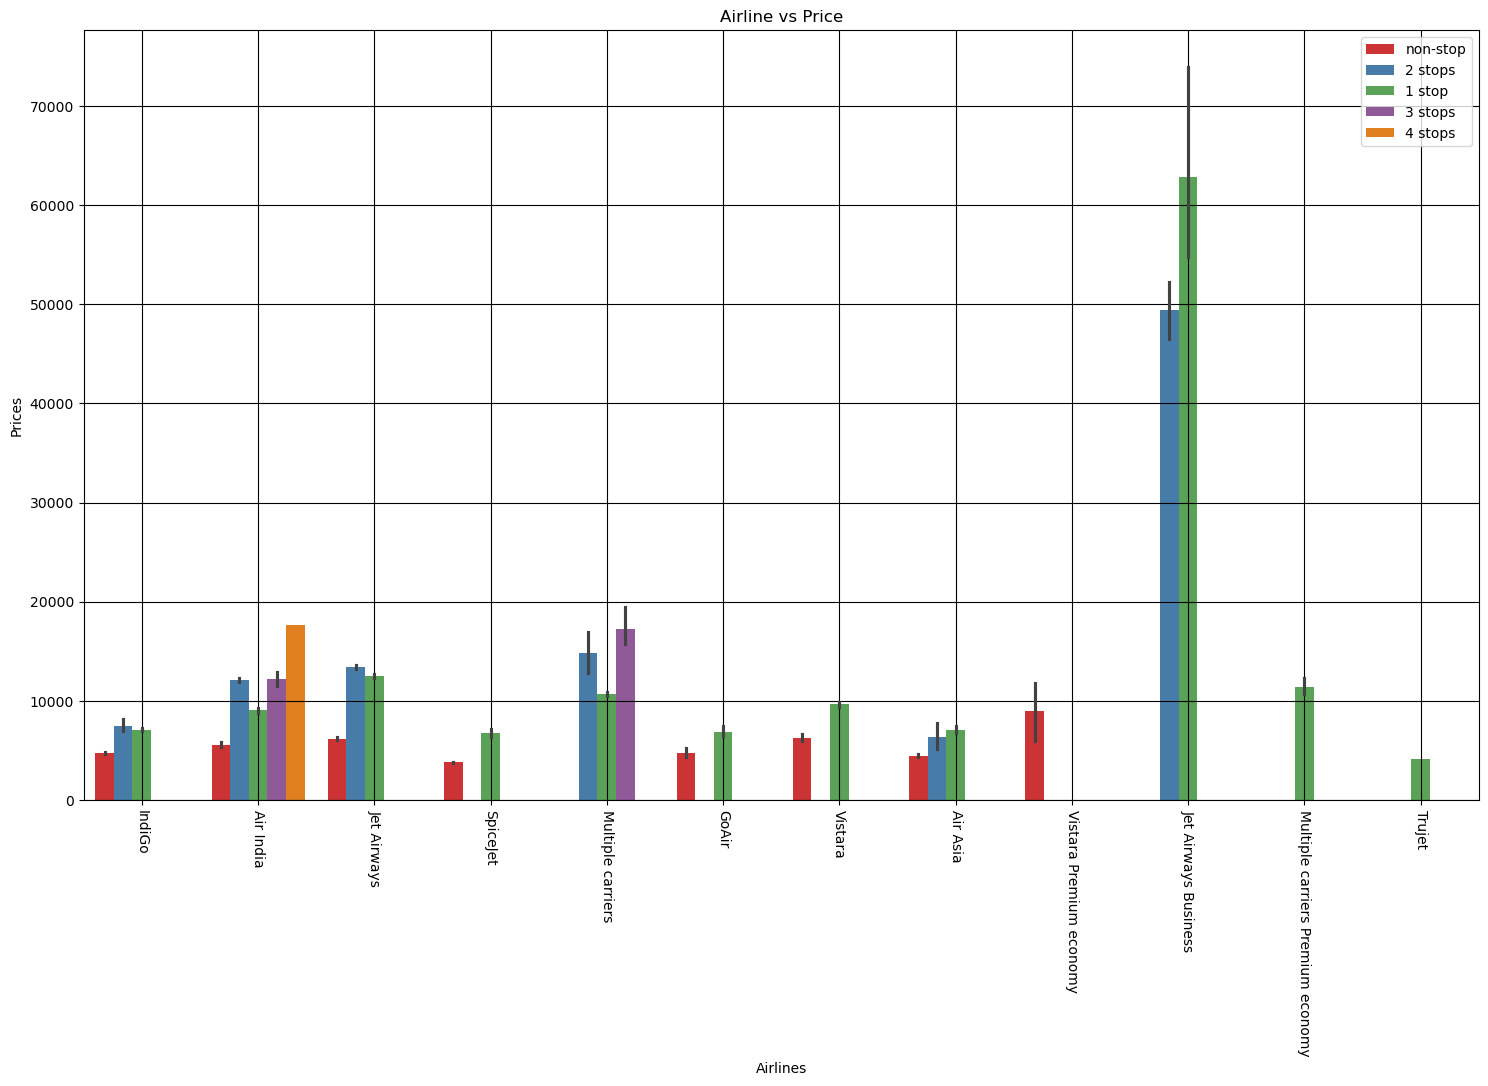

In [134]:
plt.figure(figsize=(18,10))
ax=sns.barplot(x='Airline',y='Price',data=df,hue='Total_Stops',palette='Set1')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.xticks(rotation=270)
plt.title('Airline vs Price')
plt.xlabel('Airlines')
plt.ylabel('Prices')
plt.grid(True,color='black')
plt.legend(loc='upper right')
plt.show()

In [135]:
df.Source.value_counts()

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

C:\temp\ipykernel_14724\2186169868.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




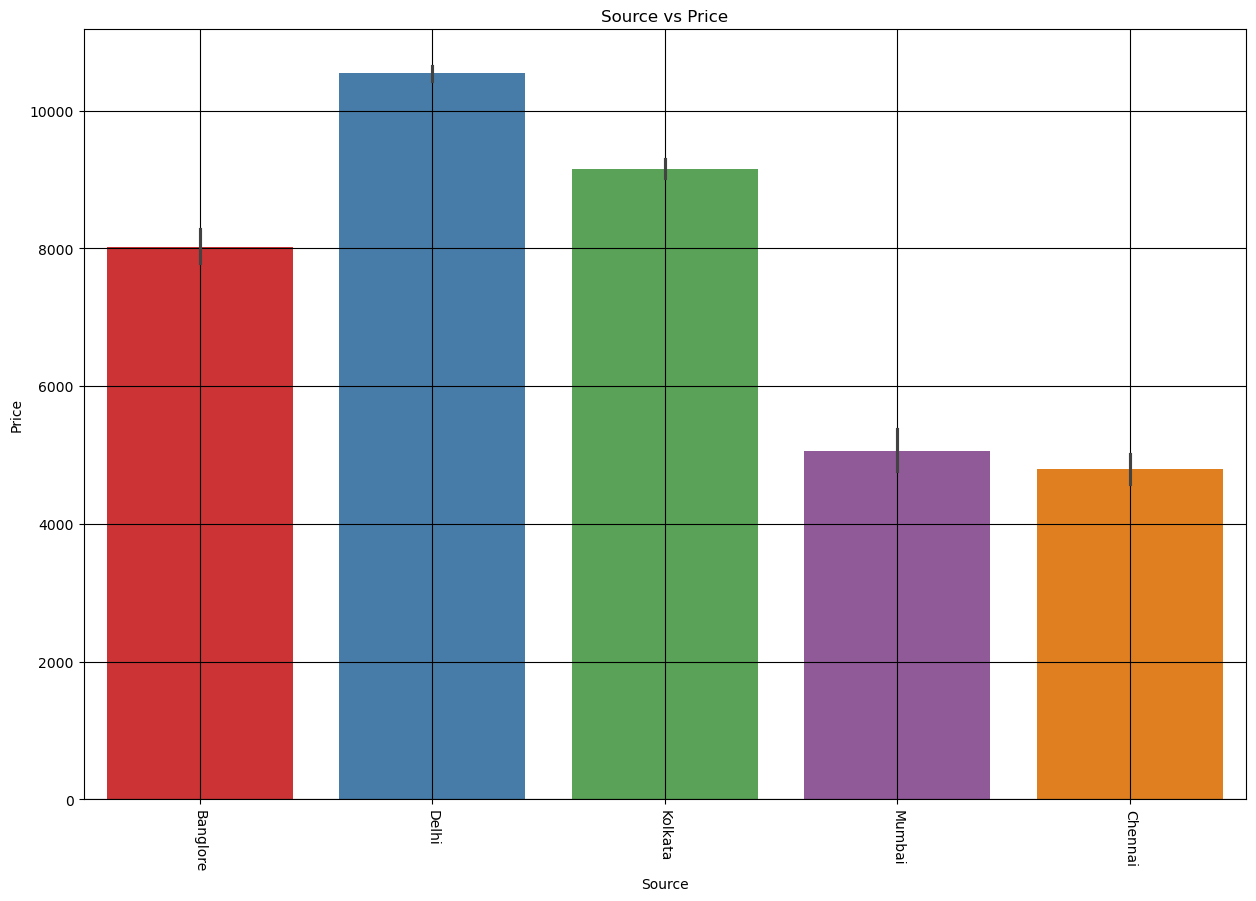

In [148]:
plt.figure(figsize=(15,10))
sns.barplot(x='Source',y='Price',data=df.sort_values('Price',ascending=False),palette='Set1')
plt.title('Source vs Price')
plt.xticks(rotation=270)
plt.xlabel('Source')
plt.ylabel('Price')
#plt.legend(loc='upper right')
plt.grid(True,color='black')
plt.show()

In [149]:
df['Destination'].value_counts()

Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

C:\temp\ipykernel_14724\3107510710.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




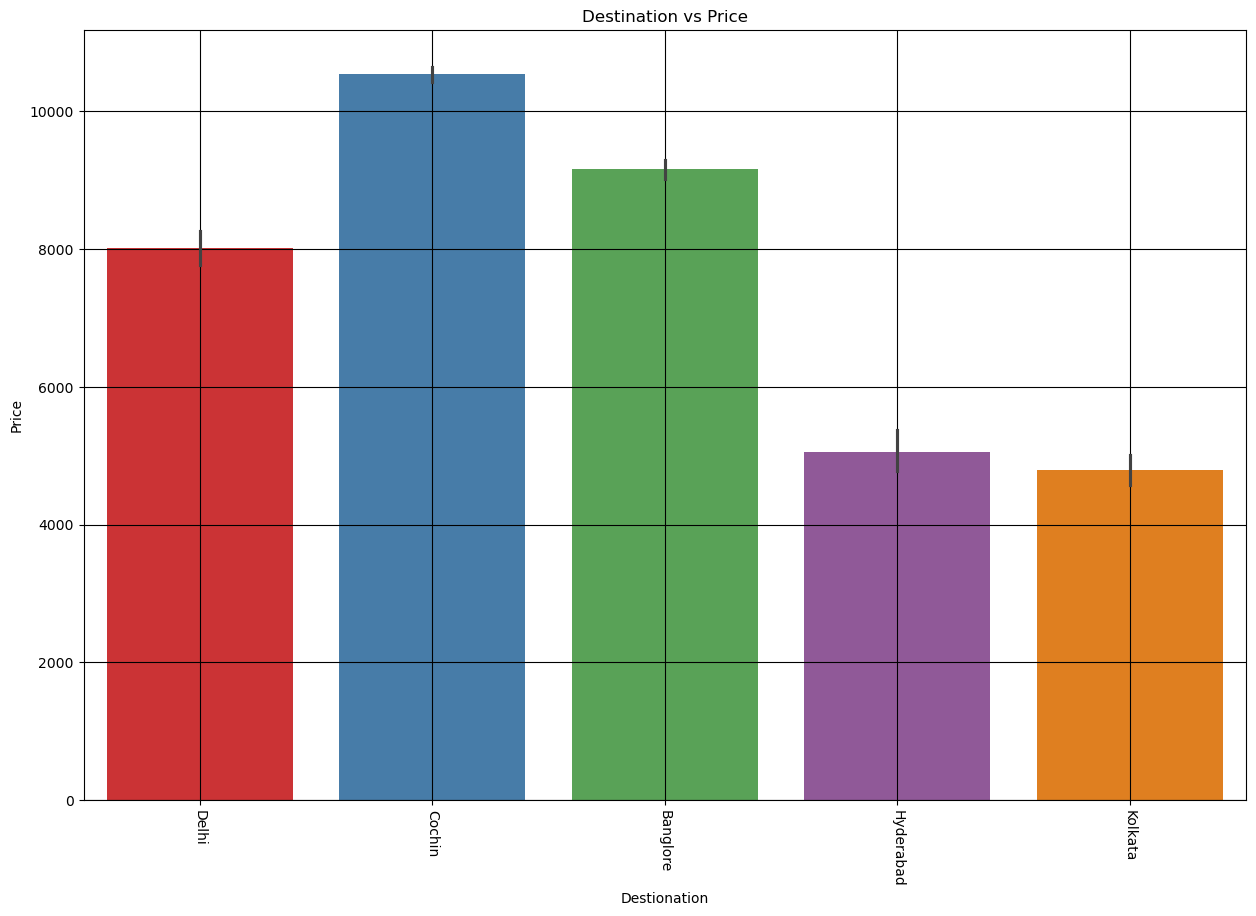

In [157]:
plt.figure(figsize=(15,10))
sns.barplot(x='Destination',y='Price',data=df.sort_values('Price',ascending=False),palette='Set1')
plt.title('Destination vs Price')
plt.xlabel('Destionation')
plt.ylabel('Price')
plt.xticks(rotation=270)
plt.grid(True,color='black')
plt.show()

In [156]:
for i in df:
    df.replace('New Delhi','Delhi',inplace=True)
    

In [161]:
display(df['Destination'].unique())

array(['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad'],
      dtype=object)

In [162]:
df.Destination.value_counts()

Destination
Cochin       4536
Banglore     2871
Delhi        2197
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [163]:
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr,duration_min
0,IndiGo,Banglore,Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,Air India,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,00
10681,Vistara,Banglore,Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [164]:
df_corr=df.iloc[:,7:]
display(df_corr)


,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr,duration_min
0,24,3,22,20,1,10,2,50
1,1,5,5,50,13,15,7,25
2,9,6,9,25,4,25,19,00
3,12,5,18,5,23,30,5,25
4,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...
10678,9,4,19,55,22,25,2,30
10679,27,4,20,45,23,20,2,35
10680,27,4,8,20,11,20,3,00
10681,1,3,11,30,14,10,2,40


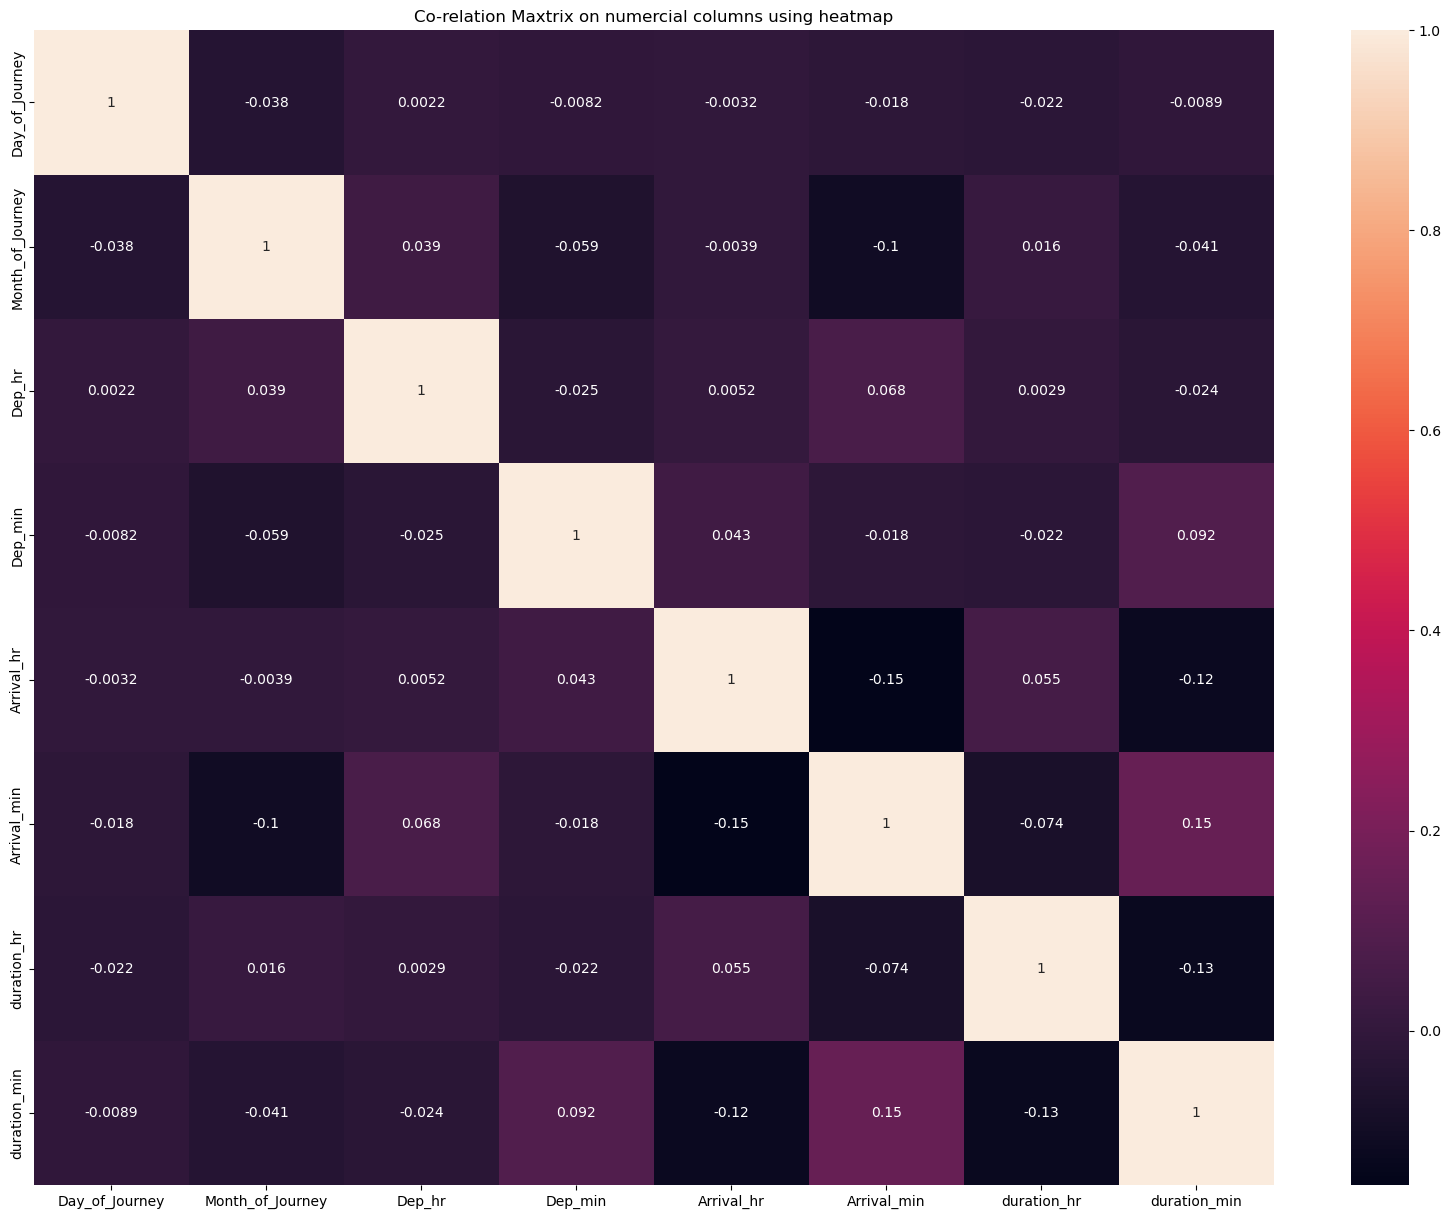

In [166]:
# create the co-relation matrix using heatmap to showw graph
plt.figure(figsize=(20,15))
sns.heatmap(df_corr.corr(),annot=True)
plt.title('Co-relation Maxtrix on numercial columns using heatmap')
plt.show()


In [167]:
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr,duration_min
0,IndiGo,Banglore,Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,Air India,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,00
10681,Vistara,Banglore,Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [169]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [171]:
df['Total_Stops']=df['Total_Stops'].map({'non-stop':0,'2 stops':2,'1 stop':1,'3 stops':3,'4 stops':4})
display(df.head())

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr,duration_min
0,IndiGo,Banglore,Delhi,BLR → DEL,0,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,9,25,4,25,19,00
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,Delhi,BLR → NAG → DEL,1,No info,13302,1,3,16,50,21,35,4,45


In [172]:
# now we will do the one-hot encoding on Airline using pd.get_dummies
air_dummy=pd.get_dummies(df['Airline'],drop_first=True,dtype=int)
display(air_dummy)

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
10678,0,0,0,0,0,0,0,0,0,0,0
10679,1,0,0,0,0,0,0,0,0,0,0
10680,0,0,0,1,0,0,0,0,0,0,0
10681,0,0,0,0,0,0,0,0,0,1,0


In [174]:
# we will one hot encoding source and destination using get_dummies
source_dest_dummy=pd.get_dummies(df[['Source','Destination']],drop_first=True,dtype=int)
display(source_dest_dummy)

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata
0,0,0,0,0,0,1,0,0
1,0,0,1,0,0,0,0,0
2,0,1,0,0,1,0,0,0
3,0,0,1,0,0,0,0,0
4,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...
10678,0,0,1,0,0,0,0,0
10679,0,0,1,0,0,0,0,0
10680,0,0,0,0,0,1,0,0
10681,0,0,0,0,0,1,0,0


In [175]:
df=pd.concat([air_dummy,source_dest_dummy,df],axis=1)
display(df)

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,...,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,duration_hr,duration_min
0,0,0,1,0,0,0,0,0,0,0,...,No info,3897,24,3,22,20,1,10,2,50
1,1,0,0,0,0,0,0,0,0,0,...,No info,7662,1,5,5,50,13,15,7,25
2,0,0,0,1,0,0,0,0,0,0,...,No info,13882,9,6,9,25,4,25,19,00
3,0,0,1,0,0,0,0,0,0,0,...,No info,6218,12,5,18,5,23,30,5,25
4,0,0,1,0,0,0,0,0,0,0,...,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,0,0,0,0,0,0,0,0,0,...,No info,4107,9,4,19,55,22,25,2,30
10679,1,0,0,0,0,0,0,0,0,0,...,No info,4145,27,4,20,45,23,20,2,35
10680,0,0,0,1,0,0,0,0,0,0,...,No info,7229,27,4,8,20,11,20,3,00
10681,0,0,0,0,0,0,0,0,0,1,...,No info,12648,1,3,11,30,14,10,2,40


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Air India                          10682 non-null  int64 
 1   GoAir                              10682 non-null  int64 
 2   IndiGo                             10682 non-null  int64 
 3   Jet Airways                        10682 non-null  int64 
 4   Jet Airways Business               10682 non-null  int64 
 5   Multiple carriers                  10682 non-null  int64 
 6   Multiple carriers Premium economy  10682 non-null  int64 
 7   SpiceJet                           10682 non-null  int64 
 8   Trujet                             10682 non-null  int64 
 9   Vistara                            10682 non-null  int64 
 10  Vistara Premium economy            10682 non-null  int64 
 11  Source_Chennai                     10682 non-null  int64 
 12  Source_De

In [177]:
df.drop(['Airline','Source','Destination'],inplace=True,axis=1)

In [178]:
df.shape

(10682, 31)

In [180]:
df_test=pd.read_excel('Test_set.xlsx')
df_test

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info
...,...,...,...,...,...,...,...,...,...,...
2666,Air India,6/06/2019,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info
2667,IndiGo,27/03/2019,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info
2668,Jet Airways,6/03/2019,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info
2669,Air India,6/03/2019,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info


In [196]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Airline           2671 non-null   object        
 1   Date_of_Journey   2671 non-null   datetime64[ns]
 2   Source            2671 non-null   object        
 3   Destination       2671 non-null   object        
 4   Route             2671 non-null   object        
 5   Dep_Time          2671 non-null   object        
 6   Arrival_Time      2671 non-null   object        
 7   Duration          2671 non-null   object        
 8   Total_Stops       2671 non-null   object        
 9   Additional_Info   2671 non-null   object        
 10  Day_of_Journey    2671 non-null   int32         
 11  Month_of_Journey  2671 non-null   int32         
 12  Dep_hr            2671 non-null   int32         
 13  Dep_min           2671 non-null   int32         
 14  Arrival_hr        2671 n

In [185]:
df_test['Date_of_Journey']=pd.to_datetime(df_test['Date_of_Journey'],format='%d/%m/%Y')

In [187]:
df_test['Day_of_Journey']=(df_test['Date_of_Journey']).dt.day
df_test['Month_of_Journey']=(df_test['Date_of_Journey']).dt.month

In [192]:
df_test['Dep_hr']=pd.to_datetime(df_test['Dep_Time']).dt.hour
df_test['Dep_min']=pd.to_datetime(df_test['Dep_Time']).dt.minute

C:\temp\ipykernel_14724\1982508780.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [194]:
df_test

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min
0,Jet Airways,2019-06-06,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info,6,6,17,30
1,IndiGo,2019-05-12,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info,12,5,6,20
2,Jet Airways,2019-05-21,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included,21,5,19,15
3,Multiple carriers,2019-05-21,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info,21,5,8,0
4,Air Asia,2019-06-24,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info,24,6,23,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,Air India,2019-06-06,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info,6,6,20,30
2667,IndiGo,2019-03-27,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info,27,3,14,20
2668,Jet Airways,2019-03-06,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info,6,3,21,50
2669,Air India,2019-03-06,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info,6,3,4,0


In [195]:
df_test['Arrival_hr']=pd.to_datetime(df_test['Arrival_Time']).dt.hour
df_test['Arrival_min']=pd.to_datetime(df_test['Arrival_Time']).dt.minute

C:\temp\ipykernel_14724\210379740.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\temp\ipykernel_14724\210379740.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [197]:
a=df_test['Duration'].str.split(' ',expand=True)
a[1].fillna('00m',inplace=True)


C:\temp\ipykernel_14724\1044508399.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [198]:
a

,0,1
0,10h,55m
1,4h,00m
2,23h,45m
3,13h,00m
4,2h,50m
...,...,...
2666,23h,55m
2667,2h,35m
2668,6h,35m
2669,15h,15m


In [199]:
df_test['dur_hr']=a[0].apply(lambda x: x[:-1])
df_test['dur_min']=a[1].apply(lambda x: x[:-1])

In [200]:
df_test

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,dur_hr,dur_min
0,Jet Airways,2019-06-06,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info,6,6,17,30,4,25,10,55
1,IndiGo,2019-05-12,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info,12,5,6,20,10,20,4,00
2,Jet Airways,2019-05-21,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included,21,5,19,15,19,0,23,45
3,Multiple carriers,2019-05-21,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info,21,5,8,0,21,0,13,00
4,Air Asia,2019-06-24,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info,24,6,23,55,2,45,2,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,Air India,2019-06-06,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info,6,6,20,30,20,25,23,55
2667,IndiGo,2019-03-27,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info,27,3,14,20,16,55,2,35
2668,Jet Airways,2019-03-06,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info,6,3,21,50,4,25,6,35
2669,Air India,2019-03-06,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info,6,3,4,0,19,15,15,15


In [208]:
df_test.columns

Index(['Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Vistara', 'Vistara Premium economy', 'Source_Chennai', 'Source_Delhi',
       'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Destination_New Delhi', 'Airline', 'Source', 'Destination', 'Route',
       'Total_Stops', 'Additional_Info', 'Day_of_Journey', 'Month_of_Journey',
       'Dep_hr', 'Dep_min', 'Arrival_hr', 'Arrival_min', 'dur_hr', 'dur_min'],
      dtype='object')

In [206]:
df_test['Total_Stops'].unique()

array([1, 0, 2, 3, 4])

In [202]:
df_test.drop(['Date_of_Journey','Duration','Arrival_Time','Dep_Time'],axis=1,inplace=True)

In [205]:
df_test['Total_Stops']=df_test['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4})

In [207]:
air_dummy=pd.get_dummies(df_test['Airline'],drop_first=True,dtype=int)
source_dest_dummy=pd.get_dummies(df_test[['Source','Destination']],drop_first=True,dtype=int)
df_test=pd.concat([air_dummy,source_dest_dummy,df_test],axis=1)

In [210]:
df_test

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Vistara,Vistara Premium economy,...,Total_Stops,Additional_Info,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,dur_hr,dur_min
0,0,0,0,1,0,0,0,0,0,0,...,1,No info,6,6,17,30,4,25,10,55
1,0,0,1,0,0,0,0,0,0,0,...,1,No info,12,5,6,20,10,20,4,00
2,0,0,0,1,0,0,0,0,0,0,...,1,In-flight meal not included,21,5,19,15,19,0,23,45
3,0,0,0,0,0,1,0,0,0,0,...,1,No info,21,5,8,0,21,0,13,00
4,0,0,0,0,0,0,0,0,0,0,...,0,No info,24,6,23,55,2,45,2,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,1,0,0,0,0,0,0,0,0,0,...,1,No info,6,6,20,30,20,25,23,55
2667,0,0,1,0,0,0,0,0,0,0,...,0,No info,27,3,14,20,16,55,2,35
2668,0,0,0,1,0,0,0,0,0,0,...,1,No info,6,3,21,50,4,25,6,35
2669,1,0,0,0,0,0,0,0,0,0,...,1,No info,6,3,4,0,19,15,15,15


In [211]:
df_test.columns

Index(['Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Vistara', 'Vistara Premium economy', 'Source_Chennai', 'Source_Delhi',
       'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Destination_New Delhi', 'Airline', 'Source', 'Destination', 'Route',
       'Total_Stops', 'Additional_Info', 'Day_of_Journey', 'Month_of_Journey',
       'Dep_hr', 'Dep_min', 'Arrival_hr', 'Arrival_min', 'dur_hr', 'dur_min'],
      dtype='object')

In [212]:
df_test.drop(['Airline','Source','Destination','Additional_Info','Route'],axis=1,inplace=True)
df_test

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Vistara,Vistara Premium economy,...,Destination_New Delhi,Total_Stops,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,dur_hr,dur_min
0,0,0,0,1,0,0,0,0,0,0,...,0,1,6,6,17,30,4,25,10,55
1,0,0,1,0,0,0,0,0,0,0,...,0,1,12,5,6,20,10,20,4,00
2,0,0,0,1,0,0,0,0,0,0,...,0,1,21,5,19,15,19,0,23,45
3,0,0,0,0,0,1,0,0,0,0,...,0,1,21,5,8,0,21,0,13,00
4,0,0,0,0,0,0,0,0,0,0,...,0,0,24,6,23,55,2,45,2,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,1,0,0,0,0,0,0,0,0,0,...,0,1,6,6,20,30,20,25,23,55
2667,0,0,1,0,0,0,0,0,0,0,...,0,0,27,3,14,20,16,55,2,35
2668,0,0,0,1,0,0,0,0,0,0,...,0,1,6,3,21,50,4,25,6,35
2669,1,0,0,0,0,0,0,0,0,0,...,0,1,6,3,4,0,19,15,15,15


In [215]:
df_test.shape

(2671, 28)

In [216]:
df.columns

Index(['Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Trujet', 'Vistara', 'Vistara Premium economy', 'Source_Chennai',
       'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Route', 'Total_Stops', 'Additional_Info', 'Price', 'Day_of_Journey',
       'Month_of_Journey', 'Dep_hr', 'Dep_min', 'Arrival_hr', 'Arrival_min',
       'duration_hr', 'duration_min'],
      dtype='object')

In [217]:
x=df.drop(['Route','Price','Additional_Info'],axis=1)
y=df['Price']

In [219]:
print(x.shape)
print(y.shape)

(10682, 28)
(10682,)


In [237]:
# now we will do the modeling 
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score,r2_score
ET_Model=ExtraTreesClassifier(n_estimators=1,n_jobs=1)
ET_Model.fit(x,y)

,n_estimators,1
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [239]:
y_predict=ET_Model.predict(x)
print('R2_score:',r2_score(y,y_predict))

R2_score: 0.926804031540084


In [240]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [242]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score,r2_score
ET_Model=ExtraTreesClassifier(n_estimators=3,n_jobs=1)
ET_Model.fit(x_train,y_train)

,n_estimators,3
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [243]:
y_predict=ET_Model.predict(x_test)
print('R2_score:',r2_score(y_test,y_predict))

R2_score: 0.6052794745570069


In [244]:
y_predict=ET_Model.predict(x_train)
print('R2_score:',r2_score(y_train,y_predict))

R2_score: 0.9390340337022761


In [246]:
from sklearn.ensemble import RandomForestRegressor
RF_Model=RandomForestRegressor()
RF_Model.fit(x_train,y_train)
y_predict=RF_Model.predict(x_test)
print('R2_score:',r2_score(y_test,y_predict))


R2_score: 0.8031597724503639


In [247]:
y_predict=RF_Model.predict(x_train)
print('R2_score:',r2_score(y_train,y_predict))  

R2_score: 0.953344358267903


In [251]:
[int(x) for x in np.linspace(start=80,stop=1500,num=10)]

[80, 237, 395, 553, 711, 868, 1026, 1184, 1342, 1500]

In [253]:
from sklearn.model_selection import RandomizedSearchCV
n_estimators=[int(x) for x in np.linspace(start=80,stop=1500,num=10)]
max_features=['auto','sqrt']
max_depth=[int(x) for x in np.linspace(6,45,num=5)]
min_samples_split=[2,5,10,15,100]
min_samples_leaf=[1,2,5,10]

# Create random grid
rand_grid={'n_estimators':n_estimators,
           'max_features':max_features,
           'max_depth':max_depth,
           'min_samples_split':min_samples_split,
           'min_samples_leaf':min_samples_leaf
    
}

rf=RandomForestRegressor()

rCV=RandomizedSearchCV(estimator=rf,param_distributions=rand_grid,scoring='neg_mean_squared_error',n_iter=20,cv=5,random_state=42,n_jobs=-1)



In [254]:
rCV.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning:


60 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
  

,estimator,RandomForestRegressor()
,param_distributions,"{'max_depth': [6, 15, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [255]:
rf_pred=rCV.predict(x_test)
display(rf_pred)

array([12029.1014496 ,  4368.74777166,  6214.49042845, ...,
       11546.3437133 , 10288.44837473,  8698.41833155], shape=(2137,))

In [257]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print('MAE:',mean_absolute_error(y_test,rf_pred))
print('MSE:',mean_squared_error(y_test,rf_pred))
display(r2_score(y_test,rf_pred))

MAE: 1279.66245749312
MSE: 4300248.062245066


0.7905758237623979

In [258]:
rf_pred=rCV.predict(x_train)
display(rf_pred)

array([12278.36169294,  5355.35805959,  5507.56053191, ...,
        8305.74777768, 10318.36114021,  7103.53074124], shape=(8545,))

In [259]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print('MAE:',mean_absolute_error(y_train,rf_pred))
print('MSE:',mean_squared_error(y_train,rf_pred))
display(r2_score(y_train,rf_pred))

MAE: 907.7878838616241
MSE: 2063603.7392168907


0.9037613045132552

Defaulting to user installation because normal site-packages is not writeable
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   - -------------------------------------- 3.7/100.2 MB 18.6 MB/s eta 0:00:06
   -- ------------------------------------- 6.0/100.2 MB 16.6 MB/s eta 0:00:06
   --- ------------------------------------ 8.7/100.2 MB 13.8 MB/s eta 0:00:07
   ---- ----------------------------------- 11.5/100.2 MB 13.6 MB/s eta 0:00:07
   ----- ---------------------------------- 14.4/100.2 MB 13.8 MB/s eta 0:00:07
   ------- -------------------------------- 17.6/100.2 MB 13.9 MB/s eta 0:00:06
   -------- ------------------------------- 20.4/100.2 MB 13.7 MB/s eta 0:00:06
   --------- ------------------------------ 23.3/100.2 MB 13.8 MB/s eta 0:00:06
   ---------- ----------------------------- 25.7/100.2 MB 13.4 MB/s eta 0:00:06


In [266]:
from catboost import CatBoostRegressor
cat=CatBoostRegressor()
cat.fit(x_train,y_train)

Learning rate set to 0.057463
0:	learn: 4496.0523487	total: 176ms	remaining: 2m 56s
1:	learn: 4369.0922944	total: 183ms	remaining: 1m 31s
2:	learn: 4222.9149833	total: 189ms	remaining: 1m 2s
3:	learn: 4094.5526402	total: 201ms	remaining: 50.2s
4:	learn: 3998.8191754	total: 205ms	remaining: 40.7s
5:	learn: 3885.0374172	total: 208ms	remaining: 34.4s
6:	learn: 3788.6739639	total: 211ms	remaining: 29.9s
7:	learn: 3685.7693823	total: 214ms	remaining: 26.5s
8:	learn: 3590.0439987	total: 217ms	remaining: 23.9s
9:	learn: 3497.0962396	total: 220ms	remaining: 21.8s
10:	learn: 3408.4880882	total: 223ms	remaining: 20s
11:	learn: 3336.0744830	total: 226ms	remaining: 18.6s
12:	learn: 3276.4890996	total: 229ms	remaining: 17.4s
13:	learn: 3206.6669062	total: 233ms	remaining: 16.4s
14:	learn: 3139.5487006	total: 236ms	remaining: 15.5s
15:	learn: 3078.9711715	total: 239ms	remaining: 14.7s
16:	learn: 3032.9305092	total: 242ms	remaining: 14s
17:	learn: 2992.7817297	total: 246ms	remaining: 13.4s
18:	learn:

CatBoostRegressor(loss_function='RMSE')

In [286]:
cat_pred=cat.predict(x_test)
print('R2_score:',r2_score(y_test,cat_pred))

R2_score: 0.828454947920456


In [272]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(x_train,y_train)
LR_pred_test=LR.predict(x_test)
print('R2_score test:',r2_score(y_test,LR_pred_test))
LR_pred_train=LR.predict(x_train)
print('R2_score train:',r2_score(y_train,LR_pred_train))
LR_pred_all=LR.predict(x)
print('R2_score all:',r2_score(y,LR_pred_all))

R2_score test: 0.5656683922992078
R2_score train: 0.6216460317119047
R2_score all: 0.6108973360867275


In [274]:
from sklearn.linear_model import Ridge
LR_R=Ridge()
LR_R.fit(x_train,y_train)
LR_pred_test=LR.predict(x_test)
print('R2_score test:',r2_score(y_test,LR_pred_test))
LR_pred_train=LR_R.predict(x_train)
print('R2_score train:',r2_score(y_train,LR_pred_train))
LR_pred_all=LR_R.predict(x)
print('R2_score all:',r2_score(y,LR_pred_all))

R2_score test: 0.5656683922992078
R2_score train: 0.6200033004119452
R2_score all: 0.6096129663038254


In [275]:
from sklearn.linear_model import Lasso
LR_R=Lasso()
LR_R.fit(x_train,y_train)
LR_pred_test=LR.predict(x_test)
print('R2_score test:',r2_score(y_test,LR_pred_test))
LR_pred_train=LR_R.predict(x_train)
print('R2_score train:',r2_score(y_train,LR_pred_train))
LR_pred_all=LR_R.predict(x)
print('R2_score all:',r2_score(y,LR_pred_all))

R2_score test: 0.5656683922992078
R2_score train: 0.6213933696355152
R2_score all: 0.6106367517951143


In [276]:
from sklearn.neighbors import KNeighborsRegressor
LR_R=KNeighborsRegressor()
LR_R.fit(x_train,y_train)
LR_pred_test=LR.predict(x_test)
print('R2_score test:',r2_score(y_test,LR_pred_test))
LR_pred_train=LR_R.predict(x_train)
print('R2_score train:',r2_score(y_train,LR_pred_train))
LR_pred_all=LR_R.predict(x)
print('R2_score all:',r2_score(y,LR_pred_all))

R2_score test: 0.5656683922992078
R2_score train: 0.7330620701219299
R2_score all: 0.7016160101226117


In [284]:
x_train[['duration_hr','duration_min']]=x_train[['duration_hr','duration_min']].astype(int)
x_test[['duration_hr','duration_min']]=x_test[['duration_hr','duration_min']].astype(int)
x[['duration_hr','duration_min']]=x[['duration_hr','duration_min']].astype(int)

In [285]:
from lightgbm import LGBMRegressor
LR_R=LGBMRegressor()
LR_R.fit(x_train,y_train)
LR_pred_test=LR.predict(x_test)
print('R2_score test:',r2_score(y_test,LR_pred_test))
LR_pred_train=LR_R.predict(x_train)
print('R2_score train:',r2_score(y_train,LR_pred_train))
LR_pred_all=LR_R.predict(x)
print('R2_score all:',r2_score(y,LR_pred_all))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 176
[LightGBM] [Info] Number of data points in the train set: 8545, number of used features: 24
[LightGBM] [Info] Start training from score 9056.953189
R2_score test: 0.5656683922992078
R2_score train: 0.8741224170254369
R2_score all: 0.8620502224821042


In [282]:
x_train.dtypes

Air India                            int64
GoAir                                int64
IndiGo                               int64
Jet Airways                          int64
Jet Airways Business                 int64
Multiple carriers                    int64
Multiple carriers Premium economy    int64
SpiceJet                             int64
Trujet                               int64
Vistara                              int64
Vistara Premium economy              int64
Source_Chennai                       int64
Source_Delhi                         int64
Source_Kolkata                       int64
Source_Mumbai                        int64
Destination_Cochin                   int64
Destination_Delhi                    int64
Destination_Hyderabad                int64
Destination_Kolkata                  int64
Total_Stops                          int64
Day_of_Journey                       int32
Month_of_Journey                     int32
Dep_hr                               int32
Dep_min    

In [287]:
cat_pred=cat.predict(x_test)
print('R2_score:',r2_score(y_test,cat_pred))

R2_score: 0.828454947920456


In [288]:
import pickle
pickle.dump(cat,open('model_cat.pkl','wb'))
model=pickle.load(open('model_cat.pkl','rb'))

In [289]:
df.columns

Index(['Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Trujet', 'Vistara', 'Vistara Premium economy', 'Source_Chennai',
       'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Route', 'Total_Stops', 'Additional_Info', 'Price', 'Day_of_Journey',
       'Month_of_Journey', 'Dep_hr', 'Dep_min', 'Arrival_hr', 'Arrival_min',
       'duration_hr', 'duration_min'],
      dtype='object')

In [290]:
deploy_df=df.drop(['Route','Additional_Info'],axis=1)

In [291]:
deploy_df.to_csv('deploy_df.csv')